In [1]:
import sys
import datetime as dt
import pandas as pd
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) 

from data.daily_data_loader import get_asset_index_prices, get_wmco_prices
from data.resampled_data_loader import get_resampled_quotes

start_date = dt.date(2010, 1, 1)
end_date = dt.date(2025, 12, 31)

ccys = ['USD', 'EUR', 'JPY', 'GBP', 'CHF', 'NOK', 'SEK', 'AUD', 'NZD', 'CAD']
equity_close_dict = get_asset_index_prices('equity', ccys, start_date, end_date)
bond_close_dict = get_asset_index_prices('bond', ccys, start_date, end_date)
traded_instruments = [
    "AUDUSD",
    "EURUSD",
    "GBPUSD",
    "EURGBP",
    "EURJPY",
    "USDJPY",
    "USDCHF",
    "EURCHF",
    "USDCAD",
    "USDNOK",
    "USDSEK",
    "EURNOK",
    "EURSEK",
    "NZDUSD",
]
freq = pd.Timedelta(minutes=15)
fx_price_dict = get_resampled_quotes(traded_instruments, start_date, end_date, freq)
#fx_price_dict = get_wmco_prices(traded_instruments, start_date, end_date)

In [168]:
# reload
import importlib

import research.month_end as me
importlib.reload(me)

import strategy.AMEN_strategy as am
importlib.reload(am)

import trading.aggressive_trader as at
importlib.reload(at)

<module 'trading.aggressive_trader' from '/Users/jinliu/Programming/Python/systematic-trading/src/systematic_trading/trading/aggressive_trader.py'>

In [180]:
strategy = am.AmenStrategy(traded_instruments, fx_price_dict, equity_close_dict, bond_close_dict,
                        {
                            "look_back_months" : 60,
                            "use_all_countries" : False,
                            "entry_time_offset_from_month_end" : pd.Timedelta(minutes=135),
                            "exit_time_offset_from_month_end" : pd.Timedelta(-15),
                            "prediction_zscore_threshold" : 0.5,
                            "prediction_rank_threshold" : 1.0,
                            "quarterly_weight" : 0.5,
                            "quarterly_regression_mode" : "qe_only",
                        })


In [181]:
signals = strategy.generate_signals()
position_times = strategy.create_monthly_asset_returns(pd.Timedelta(hours=1)).index

In [182]:
from trading.aggressive_trader import AggressiveTrader
from analytics.performance_report import PerformanceReport

trader = AggressiveTrader(traded_instruments, fx_price_dict, signals, execute_on_next_price_tick=False)

report = PerformanceReport(traded_instruments, trader)

report.generate_performance_report()

,Sharpe_Net,Sharpe_Gross,AvgTradesPerDay,MaxDrawdown,WorstDayPnL,AvgNetPnLPerTrade,AvgGrossPnLPerTrade,AvgPosDur,MedPosDur,Q10PosDur,Q90PosDur
AUDUSD,0.188723,0.27083,0.032713,-0.025243,-0.00893,0.000137,0.000198,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00
EURUSD,0.520143,0.53993,0.031488,-0.008827,-0.004479,0.000376,0.000391,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00
GBPUSD,0.726937,0.763907,0.027393,-0.010776,-0.00556,0.00057,0.000604,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00
EURGBP,0.640387,0.697539,0.029789,-0.010281,-0.006569,0.000441,0.000486,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00
EURJPY,0.555699,0.594128,0.028581,-0.01307,-0.008904,0.000442,0.000476,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00
USDJPY,0.201651,0.234013,0.028077,-0.021576,-0.00765,0.000129,0.00015,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00
USDCHF,-0.033338,0.037612,0.031646,-0.046864,-0.008404,-0.000022,0.000025,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00
EURCHF,0.635695,0.712117,0.03218,-0.009576,-0.004678,0.000348,0.000396,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00
USDCAD,0.003803,0.054191,0.030817,-0.038515,-0.011915,0.000003,0.000041,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00
USDNOK,0.210026,0.368104,0.030647,-0.02083,-0.007394,0.000188,0.000335,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00,0 days 02:15:00


<Axes: xlabel='timestamp'>

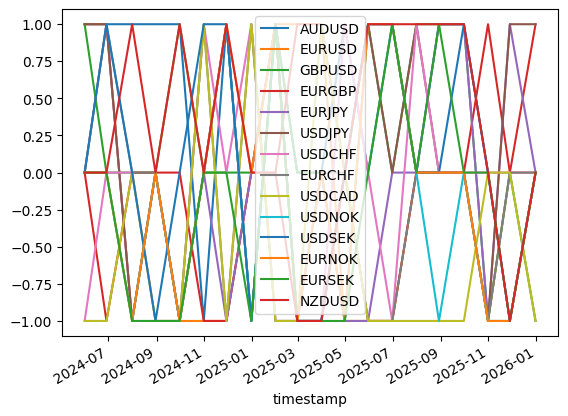

In [183]:
positions = pd.DataFrame(trader.generate_positions())
positions.loc[position_times[-20:]].plot()

<Axes: title={'center': 'GBPUSD Cumulative PnL'}, xlabel='Time', ylabel='Cumulative PnL'>

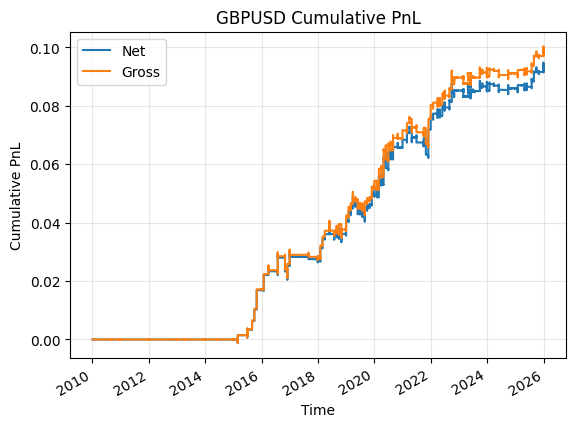

In [165]:
report.plot_cumulative_pnl('GBPUSD')

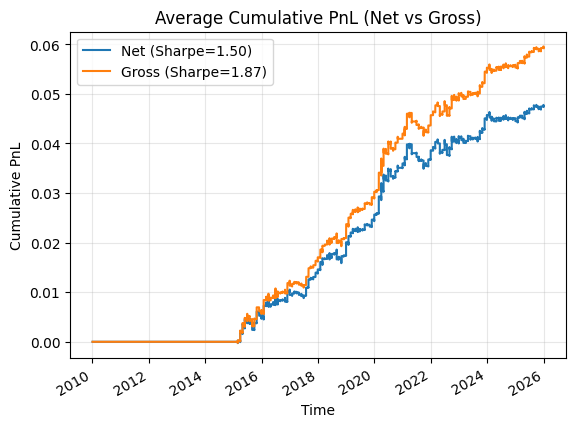

In [184]:
import numpy as np

freq_mult = pd.Timedelta(days=2) / freq

net_pnl_dict = trader.generate_net_pnl()
gross_pnl_dict = trader.generate_gross_pnl()

net_df = pd.DataFrame(net_pnl_dict).fillna(0.0)
gross_df = pd.DataFrame(gross_pnl_dict).fillna(0.0)

avg_net = net_df.mean(axis=1)
avg_gross = gross_df.mean(axis=1)

net_sharpe = np.sqrt(252 * freq_mult) * avg_net.mean() / avg_net.std() if avg_net.std() != 0 else np.nan
gross_sharpe = (
    np.sqrt(252 * freq_mult) * avg_gross.mean() / avg_gross.std() if avg_gross.std() != 0 else np.nan
)

ax = avg_net.cumsum().plot(label=f"Net (Sharpe={net_sharpe:.2f})")
avg_gross.cumsum().plot(ax=ax, label=f"Gross (Sharpe={gross_sharpe:.2f})")

ax.set_title("Average Cumulative PnL (Net vs Gross)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)


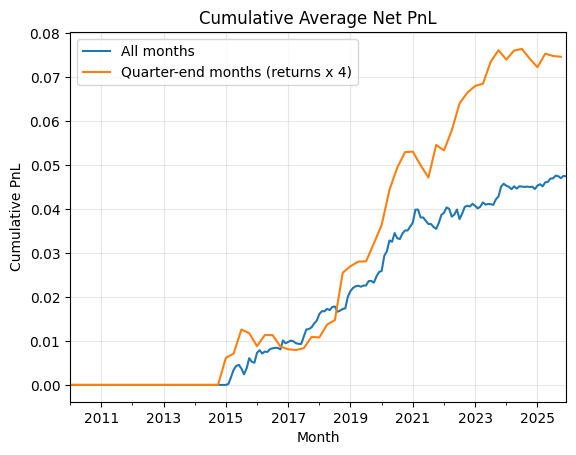

In [186]:
net_pnl_dict = trader.generate_net_pnl()

net_df = pd.DataFrame(net_pnl_dict).sort_index().fillna(0.0)

monthly_net_by_pair = net_df.resample("ME").sum()
monthly_avg_net = monthly_net_by_pair.mean(axis=1)
quarter_end_avg_net = 4 * monthly_avg_net[monthly_avg_net.index.is_quarter_end]

ax = monthly_avg_net.cumsum().plot(label="All months")
quarter_end_avg_net.cumsum().plot(ax=ax, label="Quarter-end months (returns x 4)")

ax.set_title("Cumulative Average Net PnL")
ax.set_xlabel("Month")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)

In [53]:
net_pnl_dict

{'AUDUSD': timestamp
 2010-01-03 18:00:00-05:00    NaN
 2010-01-03 18:15:00-05:00   -0.0
 2010-01-03 18:30:00-05:00   -0.0
 2010-01-03 18:45:00-05:00   -0.0
 2010-01-03 19:00:00-05:00   -0.0
                             ... 
 2025-12-31 15:45:00-05:00    0.0
 2025-12-31 16:00:00-05:00   -0.0
 2025-12-31 16:15:00-05:00   -0.0
 2025-12-31 16:30:00-05:00    0.0
 2025-12-31 16:45:00-05:00    0.0
 Length: 396249, dtype: float64,
 'EURUSD': timestamp
 2010-01-03 18:00:00-05:00    NaN
 2010-01-03 18:15:00-05:00    0.0
 2010-01-03 18:30:00-05:00   -0.0
 2010-01-03 18:45:00-05:00    0.0
 2010-01-03 19:00:00-05:00   -0.0
                             ... 
 2025-12-31 15:45:00-05:00    0.0
 2025-12-31 16:00:00-05:00    0.0
 2025-12-31 16:15:00-05:00   -0.0
 2025-12-31 16:30:00-05:00   -0.0
 2025-12-31 16:45:00-05:00    0.0
 Length: 396249, dtype: float64,
 'GBPUSD': timestamp
 2010-01-03 18:00:00-05:00    NaN
 2010-01-03 18:15:00-05:00    0.0
 2010-01-03 18:30:00-05:00    0.0
 2010-01-03 18:45:00-

In [14]:
from analytics.plot_daily_recap import plot_daily_recap

instrument = "GBPUSD"
date_range = (dt.date(2025, 9, 15), dt.date(2025, 10, 3))
close_price_df = fx_price_dict[instrument]
plot_daily_recap(instrument, date_range, close_price_df, strategy, trader)

In [ ]:
import pandas as pd

from analytics.hyperparam_optimizer import optimize_strategy_hyperparams
from strategy.AMEN_strategy import AmenStrategy

traded_instruments = ["EURUSD", "GBPUSD", "USDJPY"]

result = optimize_strategy_hyperparams(
    strategy_cls=AmenStrategy,
    strategy_kwargs={
        "traded_instruments": tuple(traded_instruments),
        "fx_price_dict": fx_price_dict,
        "equity_close_dict": equity_close_dict,
        "bond_close_dict": bond_close_dict,
    },
    instruments=traded_instruments,
    close_price_dict=fx_price_dict,  # what AggressiveTrader trades
    param_grid={
        "look_back_months": [24, 36, 60],
        "prediction_rank_threshold": [0.2, 1 / 3, 0.5],
        "prediction_zscore_threshold": [0.0, 0.5, 1.0],
        "use_all_countries": [True, False],
        "time_offset_from_month_end": [
            pd.Timedelta(days=0),
            pd.Timedelta(days=1),
        ],
    },
    metric="Sharpe_Net",
    log_path="src/systematic_trading/script/amen_hyperparam_trials.csv",
    checkpoint_every=10,
    resume=True,
)

print(result.metric_name)
print(result.best_metric_by_pair)
print(result.best_params_portfolio)
print(result.best_metric_portfolio)

In [76]:
from research.month_end import compare_quarter_end_regressions

adj_r2 = compare_quarter_end_regressions(
    strategy,
    start_date="2010-01-01",
    end_date="2025-12-31",
)

adj_r2

,monthly_adj_r_squared,quarterly_adj_r_squared,monthly_and_quarterly_adj_r_squared
ccypair,,,
AUDUSD,0.054013,0.055651,0.036140
EURUSD,-0.041229,0.041435,0.040923
GBPUSD,0.039031,0.073372,0.092018
EURGBP,0.269840,0.152797,0.358660
EURJPY,0.135283,0.005613,0.047729
USDJPY,0.131851,0.003322,0.046706
USDCHF,-0.000444,-0.041042,0.022114
EURCHF,0.072393,0.027454,0.010089
USDCAD,-0.047177,0.019214,-0.037404
